# Домашняя работа "Элементарные методы анализа временных рядов"

## Задание

- Возьмите из прошлого домашнего задания ряд — стационарный и не стационарный.
- Приблизьте оба варианта моделями из класса MA.
- Оцените качество и пришлите соображения, почему была выбрана та или иная модель.

In [234]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import boxcox
from scipy.optimize import minimize

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

%matplotlib inline

## Общие функции

In [235]:
def show_serias_smoothing(original, smoothings, title, figsize=(14, 4), style='bmh'):
    colors = ['red', 'green', 'purple', 'black']
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        plt.plot(original, color = 'blue', linewidth='1', label='original')        
        
        for i in range(len(smoothings)):
            label_text = smoothings[i][0]
            ser = smoothings[i][1]
            plt.plot(ser, color=colors[i], linewidth='1', label = label_text)
        plt.title(title)
        plt.legend()
    return

def mse_cross_val(X, train, smoothing_func):
    split = TimeSeriesSplit(n_splits=3) 
    errors = []
    
    if not isinstance(train, pd.Series):
        train = pd.Series(train)

    for train_split, test_split in split.split(train):
        train_split_ts = train.iloc[train_split]
        test_split_ts = train.iloc[test_split]
        result = smoothing_func(train_split_ts, X, len(test_split))
        predictions = result[-len(test_split_ts):]
        
        error = mean_squared_error(predictions, test_split_ts)
        errors.append(error)
    print(f'{np.mean(np.array(errors))}------------')
    return np.mean(np.array(errors))

def make_mse_cross_val_closure (series, func):
    return lambda X : mse_cross_val(X, train=series, smoothing_func=func)

## Стационарный ряд

Решил провести исследование на одном и том же ряде в исходном нестационарном виде и в преобразованном стационарном виде.

### Получим стационарный ряд

In [236]:
st_series = pd.read_csv("Series/international-airline-passengers.csv")['Count']
st_series = boxcox(st_series, 0)
st_series = st_series[1:] - st_series[:-1]
st_series = st_series[12:] - st_series[:-12]

### Применим экспоненциальное сглаживание

In [237]:
def exponential_moving_average(series, alpha, n_pred=None):
    result = [series[0]]
    for n in range(1, len(series)):
        result.append(alpha * series[n-1] + (1 - alpha) * result[n-1])
    if not n_pred:
        return pd.Series(result)
    
    predictions = [alpha * series[len(series) - 1] + (1 - alpha) * result[-1]]

    for _ in range(n_pred):
        res = alpha * predictions[-1] + (1 - alpha) * result[-1]
        result.append(res)
        predictions.append(res)
    
    return pd.concat([series, pd.Series(predictions)], ignore_index=True)

### Изобразим сглаживание для нескольких Alpha

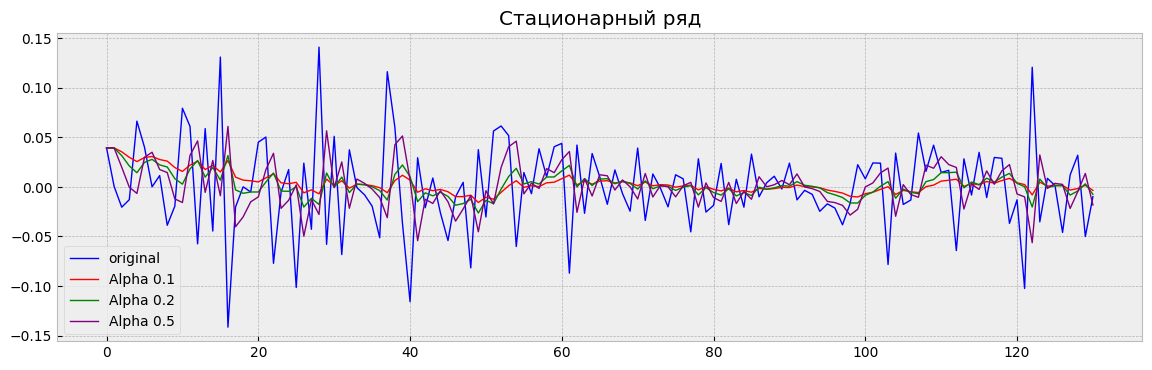

In [238]:
ema_smoothings = [
    ("Alpha 0.1", exponential_moving_average(st_series, 0.1)),
    ("Alpha 0.2", exponential_moving_average(st_series, 0.2)),
    ("Alpha 0.5", exponential_moving_average(st_series, 0.5)),
    ]

show_serias_smoothing(st_series, ema_smoothings, "Стационарный ряд")

### Приблизим сглаженный ряд к оригинальному
Будем использовать кросс-валидацию

0.0031880126039935106------------
0.0031880126039935106------------
0.0031394089644908494------------
0.0030925432059538335------------
0.0030473471070088833------------
0.002961704985213752------------
0.0028819911160105536------------
0.0027385771803633955------------
0.002613909166192195------------
0.002410404749826081------------
0.0022544190000591264------------
0.002039221638404322------------
0.0019051284501397675------------
0.0017602297301905015------------
0.0016923558497197878------------
0.0016423843353998427------------
0.0016348384217425157------------
0.0016534199049329905------------
0.0016416889656824193------------
0.0016423843353998427------------
0.0016372686372901222------------
0.001635778716699715------------
0.0016347717172401808------------
0.001635778716699715------------
0.0016346876037321718------------
0.0016348384217425157------------
0.0016346983681520258------------
0.0016347355119636852------------
0.0016346854132135468------------
0.001634698368152025

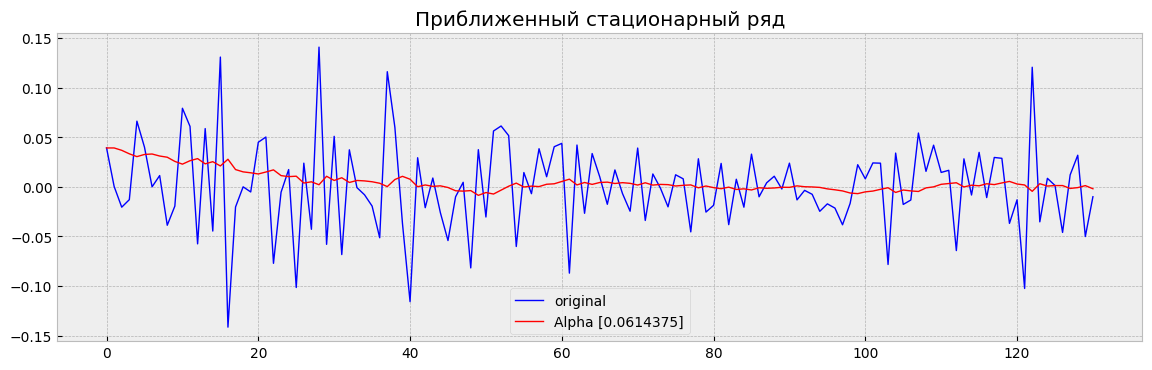

In [239]:

ema_adopted = lambda series, X, n_pred : exponential_moving_average(series=series, alpha= X[0], n_pred=n_pred)
ema_cross_val = make_mse_cross_val_closure(pd.Series(st_series), ema_adopted)
ema_cross_val([0])
opt = minimize(ema_cross_val, x0=[0], method="Nelder-Mead", bounds = [(0, 1)])

ema_smoothings = [
    ('Alpha {}'.format(opt.x), exponential_moving_average(st_series, opt.x)),
    ]

show_serias_smoothing(st_series, ema_smoothings, "Приближенный стационарный ряд")

## Нестационарный ряд

In [240]:
non_st_series = pd.read_csv("Series/international-airline-passengers.csv")['Count']

### Применим тройное экспоненциальное сглаживание
Ряд имеет трэнд и сезонность равную 12

In [241]:
def initial_trend(series, season_len):
    return sum(float(series[i + season_len] - series[i]) / season_len for i in range(len(series) - season_len)) / (len(series) - season_len)

def initial_seasonal_components(series, slen):
    seasonals = {}
    season_averages = []
    n_seasons = int(len(series)/slen)
    # compute season averages
    for j in range(n_seasons):
        season_averages.append(sum(series[slen*j:slen*j+slen])/float(slen))
    # compute initial values
    for i in range(slen):
        sum_of_vals_over_avg = 0.0
        for j in range(n_seasons):
            sum_of_vals_over_avg += series[slen*j+i]-season_averages[j]
        seasonals[i] = sum_of_vals_over_avg/n_seasons
    return seasonals

def triple_exponential_smoothing(series, slen, alpha, beta, gamma, n_preds):
    result = []
    seasonals = initial_seasonal_components(series, slen)
    for i in range(len(series)+n_preds):
        if i == 0: # initial values
            smooth = series[0]
            trend = initial_trend(series, slen)
            result.append(series[0])
            continue
        if i >= len(series): # we are forecasting
            m = i - len(series) + 1
            result.append((smooth + m*trend) + seasonals[i%slen])
        else:
            val = series[i]
            last_smooth, smooth = smooth, alpha*(val-seasonals[i%slen]) + (1-alpha)*(smooth+trend)
            trend = beta * (smooth-last_smooth) + (1-beta)*trend
            seasonals[i%slen] = gamma*(val-smooth) + (1-gamma)*seasonals[i%slen]
            result.append(smooth+trend+seasonals[i%slen])
    return result

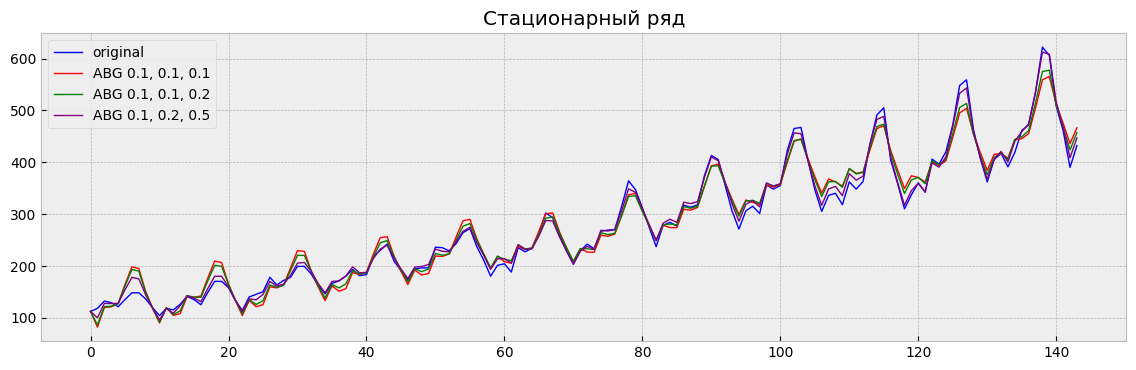

In [242]:
tema_smoothings = [
    ("ABG 0.1, 0.1, 0.1", triple_exponential_smoothing(non_st_series, 12, 0.1, 0.1, 0.1, 0)),
    ("ABG 0.1, 0.1, 0.2", triple_exponential_smoothing(non_st_series, 12, 0.1, 0.1, 0.2, 0)),
    ("ABG 0.1, 0.2, 0.5", triple_exponential_smoothing(non_st_series, 12, 0.1, 0.2, 0.5, 0)),
    ]

show_serias_smoothing(non_st_series, tema_smoothings, "Стационарный ряд")

### Приблизим нестационарный ряд

1761.9207847100454------------
1759.6985976483038------------
1761.9207847100454------------
1761.6938341462755------------
1760.2768314553957------------
1759.2237827479878------------
1757.9538564086495------------
1757.068029353941------------
1755.0010962626593------------
1754.9380633395751------------
1752.610045290902------------
1751.158028686176------------
1747.7770098866386------------
1746.6048258814915------------
1742.6490841049217------------
1741.675342388284------------
1737.5713955173676------------
1735.7787697006997------------
1731.4610069992332------------
1730.2848251046687------------
1725.1776413309715------------
1722.9406863783067------------
1713.2327608168678------------
1708.2112326046806------------
1688.4274374361169------------
1681.1410636653218------------
1653.933146954362------------
1644.5364718877515------------
1623.5922560039453------------
1620.5365863966083------------
1623.2428111385234------------
1620.3189380404535------------
1636.05281468

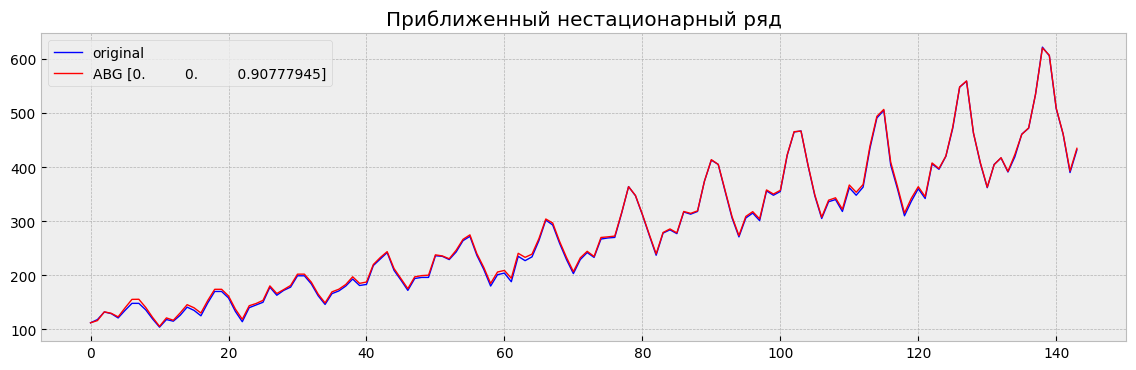

In [243]:
tema_adopted = lambda series, X, n_preds : triple_exponential_smoothing(series=series, slen = 12, alpha = X[0], beta = X[1], gamma = X[2], n_preds=n_preds)
tema_cross_val = make_mse_cross_val_closure(pd.Series(non_st_series), tema_adopted)

opt = minimize(tema_cross_val, x0=[0, 0, 0], method="Nelder-Mead", bounds = [(0, 1), (0, 1), (0, 1)])

tema_smoothings = [
    ('ABG {}'.format(opt.x), triple_exponential_smoothing(non_st_series, 12, opt.x[0], opt.x[1], opt.x[2], 0)),
    ]

show_serias_smoothing(non_st_series, tema_smoothings, "Приближенный нестационарный ряд")

### Проверка результатов
Посмотрим какую ошибку дают угаданные и оптимизированные значения альфа, бетта и гамма

In [ ]:
print("ABG 0.1, 0.1, 0.1 gives mse equal to: {}".format(tema_cross_val([0.1, 0.1, 0.1])))
print("ABG 0.1, 0.1, 0.2 gives mse equal to: {}".format(tema_cross_val([0.1, 0.1, 0.2])))
print("ABG 0.1, 0.2, 0.5 gives mse equal to: {}".format(tema_cross_val([0.1, 0.2, 0.5])))
print("ABG optimized gives mse equal to: {}".format(tema_cross_val([opt.x[0], opt.x[1], opt.x[2]])))

1920.5783627406981------------
ABG 0.1, 0.1, 0.1 gives mse equal to: 1920.5783627406981
1760.7975594010147------------
ABG 0.1, 0.1, 0.2 gives mse equal to: 1760.7975594010147
1350.8785915804203------------
ABG 0.1, 0.2, 0.5 gives mse equal to: 1350.8785915804203
1035.0446631862512------------
ABG optimized gives mse equal to: 1035.0446631862512


: 

## Выводы

Получилось приблизить стационарный и нестационарный ряды с помощью кросс-валидации. Пока не умею возвращать обратно значение стационарного ряда, чтобы проверить что же дает лучший результат - простое сглаживание на приведенном к стационарному виду ряде или же тройное экспоненциальное сглаживание на оригинальном нестационарном.